In [1]:
pip install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 57.4 MB/s eta 0:00:00


In [2]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from __future__ import division, print_function
import numpy as np
from scipy.signal import butter, filtfilt


In [3]:

np.random.seed(3)

start_scope()
delta_t = 0.1
sim_length = 3000
defaultclock.dt = delta_t*ms
### neuron model parameters ###
C = 200*pF
g_leak = 10*nS
tau = 20*ms
V_rest = -60*mV
reversal_P = 0*mV
reversal_B = -70*mV
reversal_A = -70*mV
V_th = -50*mV
V_reset = -60*mV

### synapse parameters ###
synaptic_delay = 1*ms

tau_syn_P = 2*ms
tau_syn_A = 4*ms
tau_syn_B = 1.5*ms

tau_D = 250*ms
eta_D = 0.18
e_AB = 0.5

# synapric conductance increases and connection probabilities
g_PP = 0.2*nS
p_PP = 0.01

g_PA = 6*nS
p_PA = 0.6

g_PB = 0.7*nS
p_PB = 0.5

g_AP = 0.2*nS
p_AP = 0.01

g_AA = 4*nS
p_AA = 0.6

g_AB = 8*nS
p_AB = 0.2

g_BP = 0.05*nS
p_BP = 0.2

g_BA = 7*nS
p_BA = 0.6

g_BB = 5*nS
p_BB =0.2

# population sizes
N_P = 8200
N_B = 135
N_A = 50

### currents ###
I_BG = 200*pA

# I_ext = I_BG + I_i


### equations ###
eqs = '''
I_ext : amp (shared)
dv/dt = (g_leak*(V_rest - v) - (g_P*(v-reversal_P) + g_A*(v-reversal_A) + g_B*(v-reversal_B)) + I_ext)/C : volt (unless refractory)
dg_P/dt = -g_P/tau_syn_P : siemens
dg_A/dt = -g_A/tau_syn_A : siemens
dg_B/dt = -g_B/tau_syn_B : siemens
I_syn_B = g_B*(v - reversal_B) : amp
'''
@network_operation(dt=delta_t*ms, when='start')
def current_pulse():

       if 1500*ms <= defaultclock.t <= 1510*ms:
              group_B[0:99].I_ext = np.random.uniform(0,700)*pA
       else:
              group_B.I_ext = 200*pA
              group_A.I_ext = 200*pA
              group_P.I_ext = 200*pA

#d -
### neurons groups ###
group_P = NeuronGroup(N_P, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')
group_A = NeuronGroup(N_A, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')
group_B = NeuronGroup(N_B, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1*ms, method='euler')



### synapses ###
synapse_PP = Synapses(group_P, group_P, on_pre='g_P_post += g_PP', delay=synaptic_delay)
synapse_PP.connect(p=p_PP)

synapse_AP = Synapses(group_P, group_A, on_pre='g_P_post += g_AP', delay=synaptic_delay)
synapse_AP.connect(p=p_AP)

synapse_BP = Synapses(group_P, group_B, on_pre='g_P_post += g_BP', delay=synaptic_delay)
synapse_BP.connect(p=p_BP)

synapse_AA = Synapses(group_A, group_A, on_pre='g_A_post += g_AA', delay=synaptic_delay)
synapse_AA.connect(p=p_AA)

synapse_PA = Synapses(group_A, group_P, on_pre='g_A_post += g_PA', delay=synaptic_delay)
synapse_PA.connect(p=p_PA)

synapse_BA = Synapses(group_A, group_B, on_pre='g_A_post += g_BA', delay=synaptic_delay)
synapse_BA.connect(p=p_BA)

synapse_BB = Synapses(group_B, group_B, on_pre='g_B_post += g_BB', delay=synaptic_delay)
synapse_BB.connect(p=p_BB)


# to control depression
clamp_depr = 1
eqs_std_AB = '''
       g_ab : 1
       de_AB / dt = clamp_depr * (1. - e_AB) / tau_D : 1 (clock-driven)
       '''

synapse_AB = Synapses(group_B, group_A, model=eqs_std_AB, on_pre='''
                    g_B_post += g_AB*e_AB
                    e_AB = clip(e_AB - e_AB * eta_D, 0, 1)
                      ''', method='exact', delay=synaptic_delay)
synapse_AB.connect(p=p_AB)

synapse_PB = Synapses(group_B, group_P, on_pre='g_B_post += g_PB', delay=synaptic_delay)
synapse_PB.connect(p=p_PB)


group_P.v = V_rest
group_B.v = V_rest
group_A.v = V_rest + (V_th - V_rest) * np.random.rand(N_A)


# Initialize synaptic conductances with small random values
group_P.g_P = 0.01 * nS * np.random.rand(N_P)
group_A.g_A = 0.01 * nS * np.random.rand(N_A)
group_B.g_B = 0.01 * nS * np.random.rand(N_B)

# Add PopulationRateMonitors
pop_rate_P = PopulationRateMonitor(group_P)
pop_rate_A = PopulationRateMonitor(group_A)
pop_rate_B = PopulationRateMonitor(group_B)

current_monitor = StateMonitor(group_P, 'I_syn_B', record=True)

statemon = StateMonitor(group_B, 'I_ext', record=True)
#eventmon = EventMonitor(group_B, ('pulse_on', 'I_i'), record=True)
network = Network(collect())

# Run the simulation
network.run(sim_length*ms)

WARNING    Variable I_ext is a shared variable but it will be recorded once for every target. [brian2.monitors.statemonitor]
WARNING    'e_AB' is an internal variable of group 'synapses_7', but also exists in the run namespace with the value 0.5. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


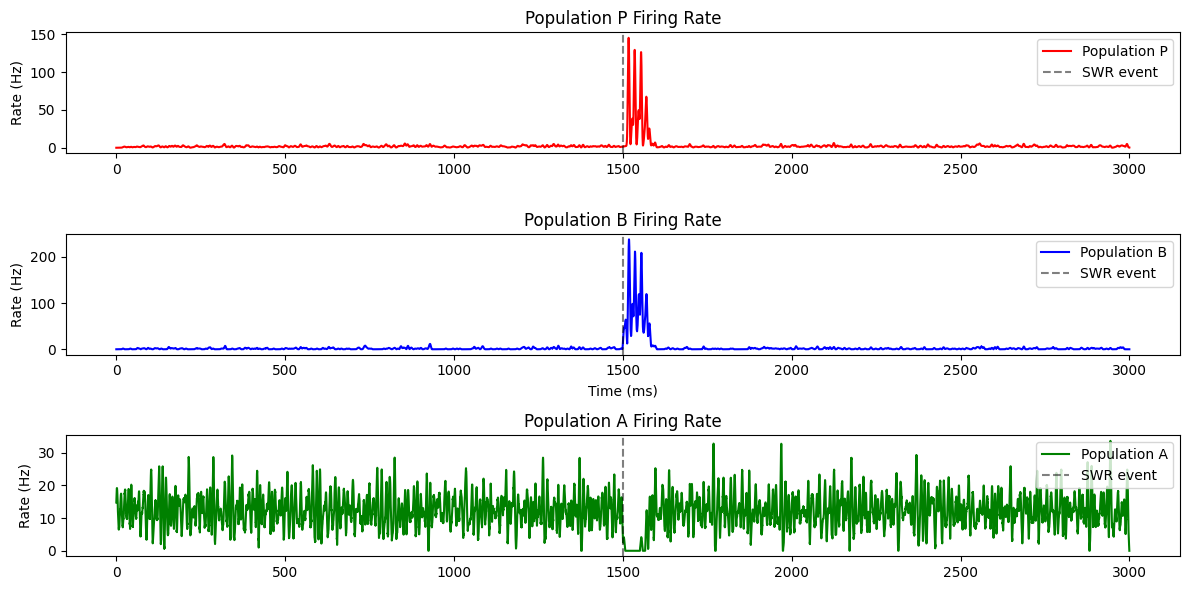

In [47]:
#Similar to the
# Plot population rates
plt.figure(figsize=(12, 6))

# Population P
plt.subplot(3, 1, 1)
plt.plot(pop_rate_P.t/ms, pop_rate_P.smooth_rate(window="gaussian", width=2*ms)/Hz, label='Population P', color="red")
plt.ylabel('Rate (Hz)')
plt.title('Population P Firing Rate')
plt.axvline(x=current_monitor.t[15000] / ms, color='black', linestyle='--', alpha=0.5, label='SWR event')  # Mark SWR events
plt.legend()

# Population B
plt.subplot(3, 1, 2)
plt.plot(pop_rate_B.t/ms, pop_rate_B.smooth_rate(window="gaussian", width=2*ms)/Hz, label='Population B', color='blue')
plt.xlabel('Time (ms)')
plt.ylabel('Rate (Hz)')
plt.title('Population B Firing Rate')
plt.axvline(x=current_monitor.t[15000] / ms, color='black', linestyle='--', alpha=0.5 , label='SWR event')  # Mark SWR events
plt.legend()

# Population A
plt.subplot(3, 1, 3)
plt.plot(pop_rate_A.t/ms, pop_rate_A.smooth_rate(window="gaussian", width=2*ms)/Hz, label='Population A', color='green')
plt.ylabel('Rate (Hz)')

plt.title('Population A Firing Rate')
plt.axvline(x=current_monitor.t[15000] / ms, color='black', linestyle='--', alpha=0.5, label='SWR event')  # Mark SWR events
plt.tight_layout()
plt.legend(loc='upper right')

plt.show()

# 1.Population P Firing Rate
**Observation**:

* The firing rate is low for most of the simulation, hovering near zero until around 1500 ms.
* At 1500 ms, the firing rate shows a large peak, indicating a transient increase in activity (potentially an SWR event).
After the event, the firing rate returns to a low level.

**Interpretation**:

* The peak indicates the onset of a sharp wave event, characterized by strong synchronization and elevated activity among pyramidal cells.
* Outside of SWRs, pyramidal cells are largely inactive, consistent with bistability (low-activity and high-activity states).



# 2.Population B Firing Rate
**Observation**:

* The firing rate of the basket cells follows a similar pattern to population P.
There is minimal activity until 1500 ms, where a sharp increase in firing occurs, peaking higher than population P.
* After the SWR event, the rate rapidly declines.

**Interpretation**:

* During SWRs, PV+ basket cells exhibit high firing rates to regulate pyramidal activity.
* This suggests that basket cells are crucial for the synchronization and termination of the SWR event.
* The firing activity is consistent with their role in providing inhibitory feedback to the pyramidal cells.


# 3. Population A Firing Rate
**Observation**:

* Population A shows irregular, higher baseline activity (compared to P and B) throughout the simulation.
*During the SWR event (around 1500 ms), the firing rate decreases slightly, indicating reduced activity.

**Interpretation:**

* Anti-SWR cells maintain consistent inhibition in the network during non-SWR periods.
* Their decreased activity during SWRs suggests that they are disinhibited, allowing pyramidal cells to enter a high-activity state.
* This aligns with the disinhibition mechanism described in the paper, where reduced activity in anti-SWR cells facilitates SWR generation.



# *Overall* SWR Dynamics
*  **Trigger:**  Around 1500 ms, the network enters an SWR event, possibly due to spontaneous fluctuations or external input.

* **Peak Activity:** The firing rates of pyramidal and basket cells peak sharply, indicating synchronized activity across excitatory and inhibitory populations.

* **Termination:** The event concludes as basket cells suppress pyramidal activity, and anti-SWR cells regain control.

* **Bistability:** The network alternates between a low-activity resting state and a high-activity SWR state.

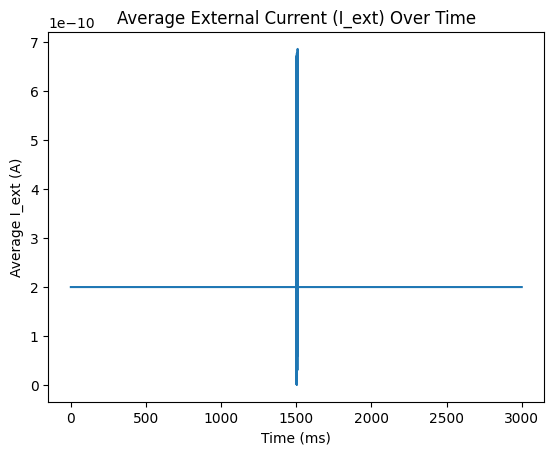

In [5]:
# Calculate the average I_ext over time
#average_I_ext = statemon.I_ext.mean(axis=0)

# Calculate the average I_ext over time
average_I_ext = np.mean(statemon.I_ext, axis=0)


# Plot the average I_ext over time
plt.plot(statemon.t / ms, average_I_ext / amp)
plt.xlabel('Time (ms)')
plt.ylabel('Average I_ext (A)')
plt.title('Average External Current (I_ext) Over Time')

plt.show()

In [6]:
"""Detect peaks in data based on their amplitude and other features."""

__author__ = "Marcos Duarte, https://github.com/demotu/BMC"
__version__ = "1.0.4"
__license__ = "MIT"


def detect_peaks(x, mph=None, mpd=1, threshold=0, edge='rising',
                 kpsh=False, valley=False, show=False, ax=None):
    """Detect peaks in data based on their amplitude and other features.
    Parameters
    ----------
    x : 1D array_like
        data.
    mph : {None, number}, optional (default = None)
        detect peaks that are greater than minimum peak height.
    mpd : positive integer, optional (default = 1)
        detect peaks that are at least separated by minimum peak distance (in
        number of data).
    threshold : positive number, optional (default = 0)
        detect peaks (valleys) that are greater (smaller) than `threshold`
        in relation to their immediate neighbors.
    edge : {None, 'rising', 'falling', 'both'}, optional (default = 'rising')
        for a flat peak, keep only the rising edge ('rising'), only the
        falling edge ('falling'), both edges ('both'), or don't detect a
        flat peak (None).
    kpsh : bool, optional (default = False)
        keep peaks with same height even if they are closer than `mpd`.
    valley : bool, optional (default = False)
        if True (1), detect valleys (local minima) instead of peaks.
    show : bool, optional (default = False)
        if True (1), plot data in matplotlib figure.
    ax : a matplotlib.axes.Axes instance, optional (default = None).
    Returns
    -------
    ind : 1D array_like
        indeces of the peaks in `x`.
    Notes
    -----
    The detection of valleys instead of peaks is performed internally by simply
    negating the data: `ind_valleys = detect_peaks(-x)`

    The function can handle NaN's
    See this IPython Notebook [1]_.
    References
    ----------
    .. [1] http://nbviewer.ipython.org/github/demotu/BMC/blob/master/notebooks/DetectPeaks.ipynb
    Examples
    --------
    # >>> from detect_peaks import detect_peaks
    # >>> x = np.random.randn(100)
    # >>> x[60:81] = np.nan
    # >>> # detect all peaks and plot data
    # >>> ind = detect_peaks(x, show=True)
    # >>> print(ind)
    # >>> x = np.sin(2*np.pi*5*np.linspace(0, 1, 200)) + np.random.randn(200)/5
    # >>> # set minimum peak height = 0 and minimum peak distance = 20
    # >>> detect_peaks(x, mph=0, mpd=20, show=True)
    # >>> x = [0, 1, 0, 2, 0, 3, 0, 2, 0, 1, 0]
    # >>> # set minimum peak distance = 2
    # >>> detect_peaks(x, mpd=2, show=True)
    # >>> x = np.sin(2*np.pi*5*np.linspace(0, 1, 200)) + np.random.randn(200)/5
    # >>> # detection of valleys instead of peaks
    # >>> detect_peaks(x, mph=0, mpd=20, valley=True, show=True)
    # >>> x = [0, 1, 1, 0, 1, 1, 0]
    # >>> # detect both edges
    # >>> detect_peaks(x, edge='both', show=True)
    # >>> x = [-2, 1, -2, 2, 1, 1, 3, 0]
    # >>> # set threshold = 2
    # >>> detect_peaks(x, threshold = 2, show=True)
    """

    x = np.atleast_1d(x).astype('float64')
    if x.size < 3:
        return np.array([], dtype=int)
    if valley:
        x = -x
    # find indexes of all peaks
    dx = x[1:] - x[:-1]
    # handle NaN's
    indnan = np.where(np.isnan(x))[0]
    if indnan.size:
        x[indnan] = np.inf
        dx[np.where(np.isnan(dx))[0]] = np.inf
    ine, ire, ife = np.array([[], [], []], dtype=int)
    if not edge:
        ine = np.where((np.hstack((dx, 0)) < 0) & (np.hstack((0, dx)) > 0))[0]
    else:
        if edge.lower() in ['rising', 'both']:
            ire = np.where((np.hstack((dx, 0)) <= 0) & (np.hstack((0, dx)) > 0))[0]
        if edge.lower() in ['falling', 'both']:
            ife = np.where((np.hstack((dx, 0)) < 0) & (np.hstack((0, dx)) >= 0))[0]
    ind = np.unique(np.hstack((ine, ire, ife)))
    # handle NaN's
    if ind.size and indnan.size:
        # NaN's and values close to NaN's cannot be peaks
        ind = ind[np.in1d(ind, np.unique(np.hstack((indnan, indnan - 1, indnan + 1))), invert=True)]
    # first and last values of x cannot be peaks
    if ind.size and ind[0] == 0:
        ind = ind[1:]
    if ind.size and ind[-1] == x.size - 1:
        ind = ind[:-1]
    # remove peaks < minimum peak height
    if ind.size and mph is not None:
        ind = ind[x[ind] >= mph]
    # remove peaks - neighbors < threshold
    if ind.size and threshold > 0:
        dx = np.min(np.vstack([x[ind] - x[ind - 1], x[ind] - x[ind + 1]]), axis=0)
        ind = np.delete(ind, np.where(dx < threshold)[0])
    # detect small peaks closer than minimum peak distance
    if ind.size and mpd > 1:
        ind = ind[np.argsort(x[ind])][::-1]  # sort ind by peak height
        idel = np.zeros(ind.size, dtype=bool)
        for i in range(ind.size):
            if not idel[i]:
                # keep peaks with the same height if kpsh is True
                idel = idel | (ind >= ind[i] - mpd) & (ind <= ind[i] + mpd) \
                              & (x[ind[i]] > x[ind] if kpsh else True)
                idel[i] = 0  # Keep current peak
        # remove the small peaks and sort back the indexes by their occurrence
        ind = np.sort(ind[~idel])

    if show:
        if indnan.size:
            x[indnan] = np.nan
        if valley:
            x = -x
        _plot(x, mph, mpd, threshold, edge, valley, ax, ind)

    return ind


def _plot(x, mph, mpd, threshold, edge, valley, ax, ind):
    """Plot results of the detect_peaks function, see its help."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print('matplotlib is not available.')
    else:
        if ax is None:
            _, ax = plt.subplots(1, 1, figsize=(8, 4))

        ax.plot(x, 'b', lw=1)
        if ind.size:
            label = 'valley' if valley else 'peak'
            label = label + 's' if ind.size > 1 else label
            ax.plot(ind, x[ind], '+', mfc=None, mec='r', mew=2, ms=8,
                    label='%d %s' % (ind.size, label))
            ax.legend(loc='best', framealpha=.5, numpoints=1)
        ax.set_xlim(-.02 * x.size, x.size * 1.02 - 1)
        ymin, ymax = x[np.isfinite(x)].min(), x[np.isfinite(x)].max()
        yrange = ymax - ymin if ymax > ymin else 1
        ax.set_ylim(ymin - 0.1 * yrange, ymax + 0.1 * yrange)
        ax.set_xlabel('Data #', fontsize=14)
        ax.set_ylabel('Amplitude', fontsize=14)
        mode = 'Valley detection' if valley else 'Peak detection'
        ax.set_title("%s (mph=%s, mpd=%d, threshold=%s, edge='%s')"
                     % (mode, str(mph), mpd, str(threshold), edge))

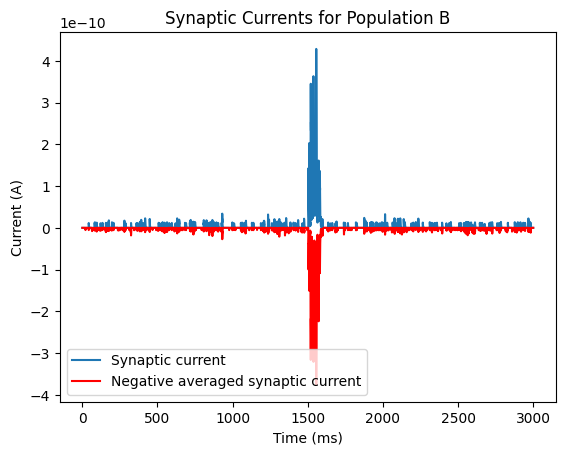

In [27]:
plt.plot(current_monitor.t/ms, current_monitor.I_syn_B[0]/amp, label="Synaptic current")

averaged = -np.average(current_monitor.I_syn_B, axis=0)

plt.plot(current_monitor.t/ms, averaged/amp, label="Negative averaged synaptic current", color='red')
plt.title('Synaptic Currents for Population B')
plt.xlabel('Time (ms)')
plt.ylabel('Current (A)')
plt.legend(loc='lower left')

# Interpretation:
* During an SWR event, the network enters a state of synchronous activation, where pyramidal cells fire rapidly, leading to increased excitatory currents.

* The temporary decrease in inhibition (negative current) is consistent with the disinhibition mechanism:

  *     Anti-SWR cells reduce their firing, allowing pyramidal cells to activate strongly.

  *  PV+ basket cells increase their activity during this period to regulate the firing, which is reflected in the rapid termination of the excitatory peak.


In [10]:
# The method create_butter_bandpass creates a Butterworth digital filter with specified parameters.
# This filter can then be applied to signals for band-pass, low-pass.

def create_butter_bandpass(lowcut, highcut, fs, order=2, btype='band'):
    """create a butterworth digital filter with given order"""
    # normalize freq with Nyquist freq (to be in [0,1])
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    if btype == 'band':
        b, a = butter(order, [low, high], btype=btype, analog=False)
    elif btype == 'low':
        b, a = butter(order, high, btype=btype, analog=False)
    else:
        b = 0
        a = 0
    return b, a # a and b are coefficient filter

b_band, a_band = create_butter_bandpass(90, 180, 1e4, 2, btype="band")
band_pass = filtfilt(b_band, a_band, -averaged)

b_low, a_low = create_butter_bandpass(0, 5, 1e4, 2, btype="low")
low_pass = filtfilt(b_low, a_low, -averaged)

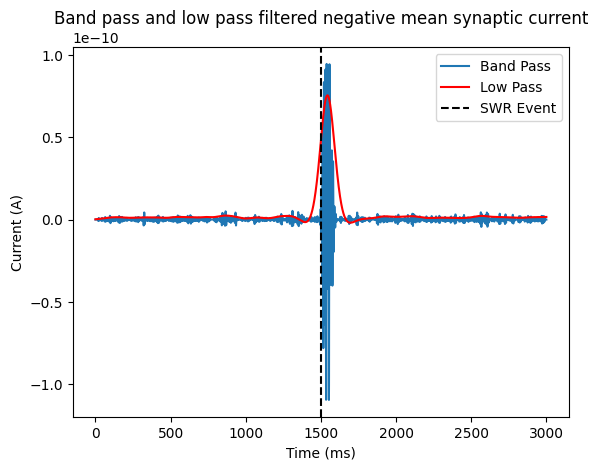

In [32]:
# plot band pass and low pass filtered negative mean synaptic current
# Similar to fig.3 in the paper
plt.plot(current_monitor.t/ms, band_pass/amp, label='Band Pass')
plt.plot(current_monitor.t/ms, low_pass/amp, label='Low Pass', color='red')
plt.axvline(x=1500, color='black', linestyle='--', label='SWR Event')
plt.title("Band pass and low pass filtered negative mean synaptic current")
plt.xlabel("Time (ms)")
plt.ylabel("Current (A)")
plt.legend()

# Implications
**SWR Detection:**

* The peak in the filtered signals indicates that the network has entered a synchronized high-activity state.

* SWRs are critical for memory consolidation, and the presence of both low and high-frequency components suggests proper event formation.
Filtering Effect:

   *   The band-pass filter isolates ripples (typically in the 90-180 Hz range), which are less visible in the raw signal.
   * The low-pass filter removes high-frequency noise, emphasizing slow-wave components of the SWR.


[7.56734276e-11]


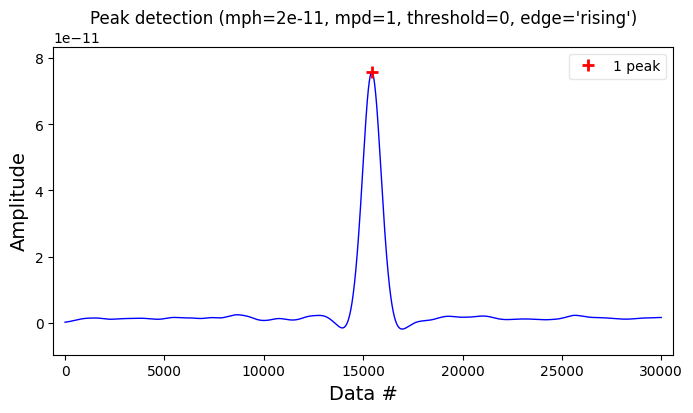

In [13]:
indx = detect_peaks(low_pass, mph=2e-11, mpd=1, threshold=0, edge='rising', valley=False, show=True)

peak_values = low_pass[indx]
print(peak_values)
